## Preparation

### Libraries import & metadata storage definitions

In [1]:
import os
import numpy as np
from time import time
from typing import Optional

import torch
from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import root_mean_squared_error
from scipy import stats
from scipy.special import softmax

from matplotlib import pyplot as plt, colors, cm

In [2]:
checkpoint_dir = "checkpoints_imagenet"
graph_dir = "graphs_imagenet"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common key functions: plots

In [3]:
figsize_squared = (30, 7)
figsize_long = (3, 15)

In [4]:
def plot_metric(trains: list, 
                tests: list, 
                epochs: int, 
                model_name: str = "model",
                dataset_name: str = "dataset",
                metric_name: str = "metric",
                graph_dir: str = "graphs"):
    
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        [i+1 for i in range(epochs)],
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i+1 for i in range(epochs)],
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    ax.set(
        title=f"{model_name} {metric_name} on {dataset_name} for {epochs} epochs",
        xlabel="epochs", xlim=(-1, epochs+1), xticks=[i for i in range(0, epochs+1, 5)],
        ylabel=metric_name
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}_{epochs}epochs.png"))
    

def centralize_colormap(values, 
                        center: float = 0):
    values_min = np.min(values)
    values_max = np.max(values)
    border = max(abs(values_min), abs(values_max))
    
    return colors.TwoSlopeNorm(
        vmin=-border,
        vcenter=center, 
        vmax=border
    )


def plot_heatmap(values,
                 figsize = None,
                 cmap_name: str = "seismic",
                 title: str = "Weights heatmap"):    
    plt.figure(figsize=figsize or (25, 3))
    plt.imshow(
        values, 
        origin="lower",
        cmap=cmap_name, 
        norm=centralize_colormap(values),
        extent=(0, len(values[0]) + 1, 0, len(values) + 1)
    )  
    plt.title(title)  
    plt.colorbar()  
    plt.show() 


def plot_colored_barplot(values,
                         values_color,
                         values_color_name: str,
                         cmap_name: str = "seismic",
                         edge_color: str = "black",
                         title: str = "Values barplot",
                         xlabel: str = "",
                         ylabel: str = "",
                         xticks: list = [],
                         xticklabels: list = []):
    fig, ax = plt.subplots(figsize=(25, 5))
    
    values_cmap = plt.get_cmap(cmap_name)
    norm = centralize_colormap(values_color)
    ax.bar(
        [i for i in range(len(values))],
        values, 
        color=values_cmap(norm(values_color)),
        edgecolor=edge_color
    )
    
    scalar_map = cm.ScalarMappable(
        cmap=values_cmap, 
        norm=norm
    )
    scalar_map.set_array([])
    colorbar = plt.colorbar(scalar_map, ax=ax)
    colorbar.set_label(values_color_name)
    
    if len(xticks):
        ax.set(
            title=title,
            xlabel=xlabel,
            xticks=xticks,
            ylabel=ylabel
        )
        ax.set_xticklabels(xticklabels, rotation=-45)
    else:
        ax.set(
            title=title,
            xlabel=xlabel,
            ylabel=ylabel
        )
    plt.grid(True, alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show() 

## Dataset download & instantiation

### ImageNet-1K

В работе рассматривается задача классификации изображений, для которой используются модель [семейства ResNet](https://docs.pytorch.org/vision/main/models/resnet.html) [версии ResNet18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) и датасет [ImageNet-1K (ILSVRC2017)](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview). 

Датасет ImageNet содержит высокого (различного) разрешения, каждое из которых аннотировано с использованием синсетов WordNet и соотносится с 1 или более из 1000 классов; классы не сбалансированы. Подсеты имеют следующую мощность:
- train - 1,3 млн изображений,
- val - 50 тыс изображений,
- test - 100 тыс изображений.

Модель для ускорения обучения инициализируется весами, предобученными на датасете ImageNet со следующими метриками точности:
- acc1: 69.758,
- acc5: 89.078

без дообучения.

In [5]:
def make_val_loader_imagenet(val_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4,
                             picture_size: int = 224):
    transforms_val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(picture_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])

    imagenet_val = datasets.ImageNet(
        root=val_dir, 
        split="val", 
        transform=transforms_val
    )

    return DataLoader(
        imagenet_val, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=num_workers, 
        pin_memory=True
    )

In [6]:
dataset_dir_imagenet = "/media/user/Hitachi/ILSVRC/Data/CLS-LOC"
dataset_name = "ImageNet"
picture_size = 224

n_classes = 1000
batch_size = 256
num_workers = 4

In [7]:
print(f"[ ] Creating dataset {dataset_name}...")
val_loader = make_val_loader_imagenet(dataset_dir_imagenet, batch_size, num_workers)
classes_names = val_loader.dataset.classes  # type: ignore
print(f"[V] Dataset {dataset_name} created")

[ ] Creating dataset ImageNet...
[V] Dataset ImageNet created


## Model preparation

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


### ResNet18 download & instantiation

In [9]:
print("[ ] Instantiating model...")
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT, progress=True)
resnet18.to(device)
resnet18_name = "ResNet18"
print(f"[V] {resnet18_name} with default weights instantiated")

[ ] Instantiating model...
[V] ResNet18 with default weights instantiated


## Main pipeline

### Pipeline: validation, binarization, weights fuse

In [10]:
seed = 42
torch.manual_seed(seed)

def validate_top1_top5_time(model, 
                            loader: DataLoader):
    device = next(model.parameters()).device

    model.eval()
    top1_correct = 0
    top5_correct = 0
    total = 0
    
    start_time = time()

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        _, preds = logits.topk(5, dim=1, largest=True, sorted=True)

        correct = preds.eq(targets.view(-1, 1))
        top1_correct += correct[:, :1].sum().item()
        top5_correct += correct.sum().item()
        total += targets.size(0)
        
    val_time = time() - start_time

    return (top1_correct / total * 100,
            top5_correct / total * 100,
            val_time)
    
def pretty_print_top1_top5_time(model, 
                                loader: DataLoader, 
                                top1_orig: float = 0,
                                top5_orig: float = 0):    
    top1_new, top5_new, val_time = validate_top1_top5_time(model, loader)
    
    if top1_orig:
        drop1 = top1_orig - top1_new
        drop1_report = f", drop: {drop1:.4f}"
    else:
        drop1, drop1_report = None, ""
    if top5_orig:
        drop5 = top5_orig - top5_new
        drop5_report = f", drop: {drop5:.4f}"
    else:
        drop5, drop5_report = None, ""
        
    print(f"    Top-1 Accuracy:  {top1_new:.4f}{drop1_report}")
    print(f"    Top-5 Accuracy:  {top5_new:.4f}{drop5_report}")
    print(f"    Validation time: {val_time:.4f} s")
    return top1_new, top5_new, val_time, drop1, drop5


avgpool_input_float, avgpool_input_bin, avgpool_input_bin_values = [], [], []
scale_bin_coeff = 4.5   # scaling coefficient for binarization hook from 'ADD-ONs: Binarizarion function choice'
def binarize_hook(module, input):
    x, = input
    x_bin = 2 ** ((x+1).log2().mul(1/scale_bin_coeff).round().mul(scale_bin_coeff)) - 1
    
    global avgpool_input_float, avgpool_input_bin, avgpool_input_bin_values
    avgpool_input_float = x
    avgpool_input_bin = x_bin
    avgpool_input_bin_values = x_bin.unique()
    
    return (x_bin,)

In [11]:
class ResNetAvgPoolFCFused(torch.nn.Module):
    def __init__(self, original_model, fused_fc_layer):
        super().__init__()
        self.conv1 = original_model.conv1
        self.bn1 = original_model.bn1 
        self.relu = original_model.relu 
        self.maxpool = original_model.maxpool 
        self.layer1 = original_model.layer1
        self.layer2 = original_model.layer2
        self.layer3 = original_model.layer3
        self.layer4 = original_model.layer4
        self.fused_fc = fused_fc_layer
            
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)     # -> [batch_size, 512, 7, 7] for ResNet18 on ImageNet
        
        x = x.flatten(1)       # -> [batch_size, 512*7*7] + normalization for ResNet18 on ImageNet
        x = self.fused_fc(x)   # -> [batch_size, 1000]       for ResNet18 on ImageNet
        return x


def fuse_avgpool_linear(model, 
                        input_size: int = 224):
    device = next(model.parameters()).device
    
    weights = model.fc.weight.data  # [1000, 512] for ResNet18 on ImageNet
    bias = model.fc.bias.data if (model.fc.bias is not None) else torch.zeros(weights.shape[0])
    
    with torch.no_grad():
        random_input = torch.randn(1, 3, input_size, input_size).to(device)
        features = model.conv1(random_input)
        features = model.bn1(features)
        features = model.relu(features)
        features = model.maxpool(features)
        features = model.layer1(features)
        features = model.layer2(features)
        features = model.layer3(features)
        features = model.layer4(features)
        H, W = features.shape[-2:] # shape = [batch, channels, H, W] = [batch_size, 512, 7, 7] for ResNet18 on ImageNet
    
    divisor = H * W
    weights_fused = weights.repeat_interleave(divisor, dim=1) / divisor
    
    return weights_fused.to(device), bias.to(device)


def replace_fc_fused_weights(model, 
                               input_size: int = 224):
    device = next(model.parameters()).device
    
    weights_fused, bias_fused = fuse_avgpool_linear(model, input_size)
    
    print("Replacing fc layer with fused one with following architecture:")
    print("    original in_features:", model.fc.in_features)
    print("    fused in_features:   ", weights_fused.shape[1])
    print("    original out_features:", model.fc.out_features)
    print("    original out_features:", weights_fused.shape[0])
    
    avgpool_fc = torch.nn.Linear(
        in_features=weights_fused.shape[1],
        out_features=model.fc.out_features,
        bias=True
    ).to(device)
    
    avgpool_fc.weight.data = weights_fused
    avgpool_fc.bias.data = bias_fused
        
    return ResNetAvgPoolFCFused(
        model, 
        avgpool_fc
    ).to(device)
    

def verify_fusion_equivalence(orig_model, 
                              fused_model, 
                              input_size: int = 224, 
                              num_tests: int = 10):
    device = next(orig_model.parameters()).device
    orig_model.eval()
    fused_model.eval()
    
    max_diff = 0.0
    with torch.no_grad():
        for _ in range(num_tests):
            x = torch.randn(2, 3, input_size, input_size, device=device)
            output_orig_model = orig_model(x)
            output_fused_model = fused_model(x)
            current_diff = torch.max(torch.abs(output_orig_model - output_fused_model)).item()
            max_diff = max(max_diff, current_diff)
    
    print(f"\nModels equivalence test on {num_tests} random inputs: {max_diff}")
    return output_orig_model, output_fused_model

In [ ]:
print("\nValidating model before binarizing:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    resnet18, val_loader
)

In [ ]:
# print("\n2. Binarizing input of avgpool layer...\n")   # throwing away avgpool
# resnet18.avgpool.register_forward_pre_hook(binarize_hook)
print("\n2. Binarizing input of fc layer...\n")          # with avgpool
resnet18.fc.register_forward_pre_hook(binarize_hook)

print("\n[ ] Validating model after binarizing avgpool input:")
top1_bin, top5_bin, val_time, _, _ = pretty_print_top1_top5_time(
    resnet18, val_loader, 
    top1_orig=top1_orig, 
    top5_orig=top5_orig
)

In [ ]:
print("Binary values of fc layer input:")
avgpool_input_bin_values

Binary values of last layer input:


tensor([ 0.0000, 21.6274], device='cuda:0')

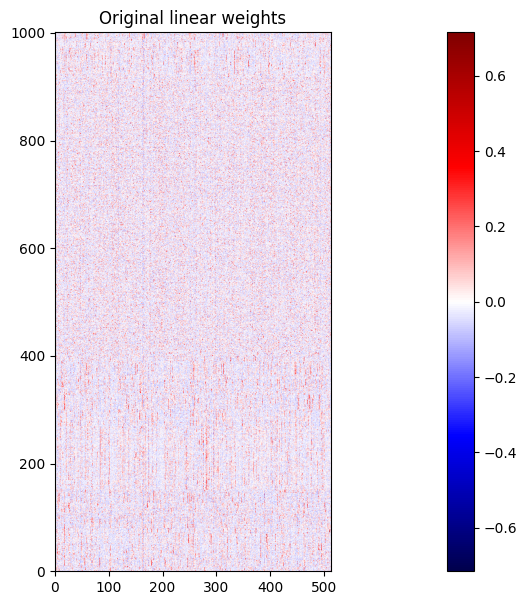

In [24]:
plot_heatmap(
    resnet18.fc.weight.data.cpu().numpy(), 
    figsize=figsize_squared, 
    title="Original linear weights"
)

In [22]:
print("\n3. Avgpool and linear layers fusing...\n")
weights_fused, bias_fused = fuse_avgpool_linear(resnet18, picture_size)
print("    Fused weight matrix shape:", weights_fused.shape)  # [n_classes, 512*H*W]


3. Avgpool and linear layers fusing...

    Fused weight matrix shape: torch.Size([1000, 25088])


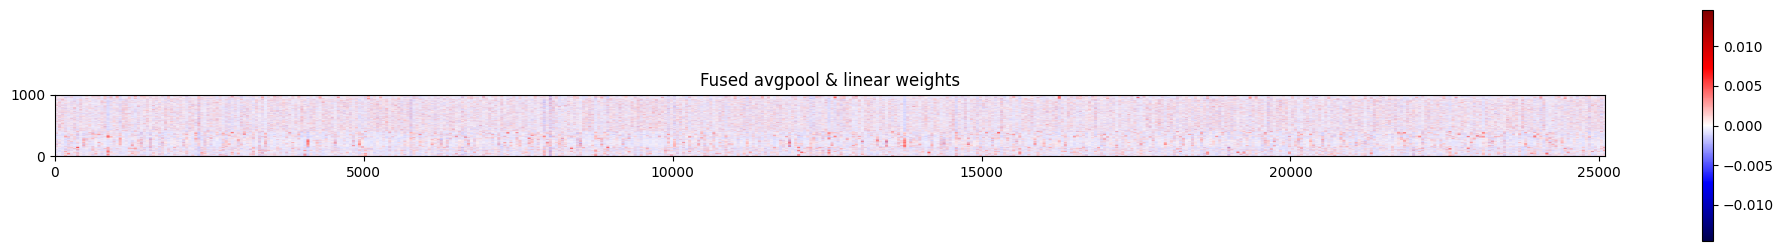

In [32]:
plot_heatmap(
    weights_fused.cpu().numpy(), 
    title="Fused avgpool & linear weights"
)

### Significant features extraction

In [ ]:
torch.manual_seed(seed)

n_svd_components = 100

print("\n4. Fused avgpool and linear layer SVD...\n")
svd = TruncatedSVD(n_components=n_svd_components, random_state=seed)
weights_reduced = svd.fit_transform(weights_fused.cpu())
print("    Explained variance ratio:", svd.explained_variance_ratio_.sum())

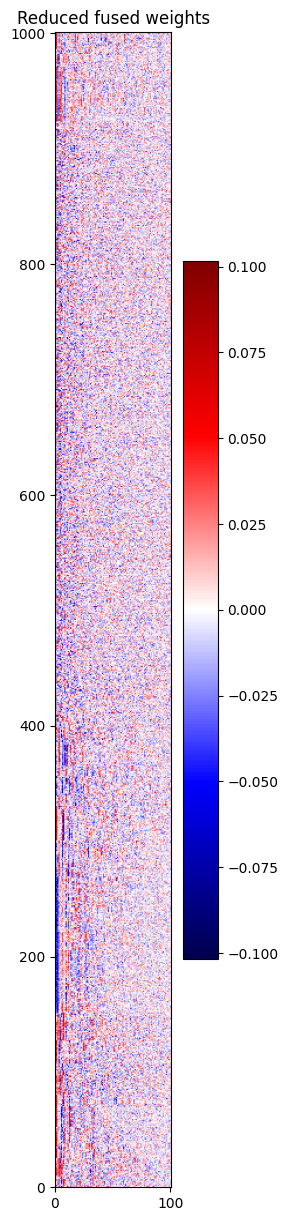

In [ ]:
plot_heatmap(weights_reduced, figsize=figsize_long, title="Reduced fused weights")

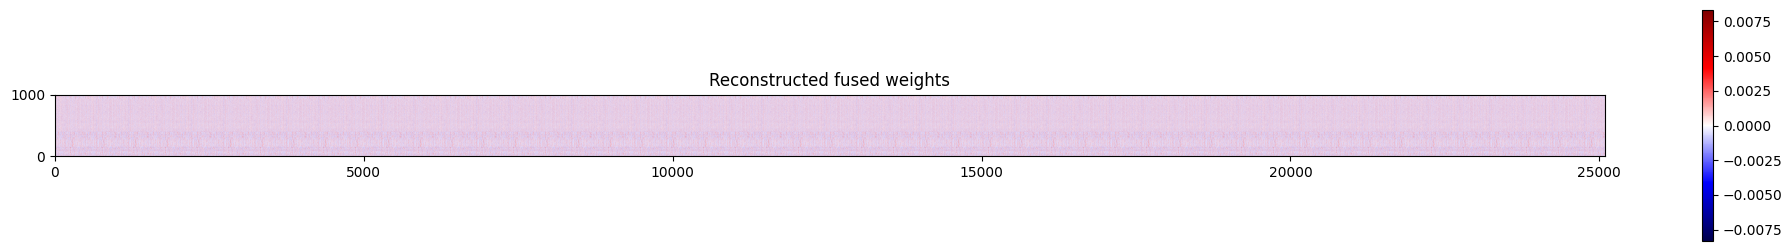

Reconstruction RMSE:      0.000878


In [ ]:
svd_right_sing_vecs = svd.components_  # [n_svd_components, 512*H*W]
weights_reconstructed = svd.inverse_transform(weights_reduced)

plot_heatmap(weights_reconstructed, title="Reconstructed fused weights")
print(f"Reconstruction RMSE:\
      {root_mean_squared_error(weights_fused.cpu().numpy(), weights_reconstructed):.6f}")

### SVD details analysis


5. Extracting significant features...



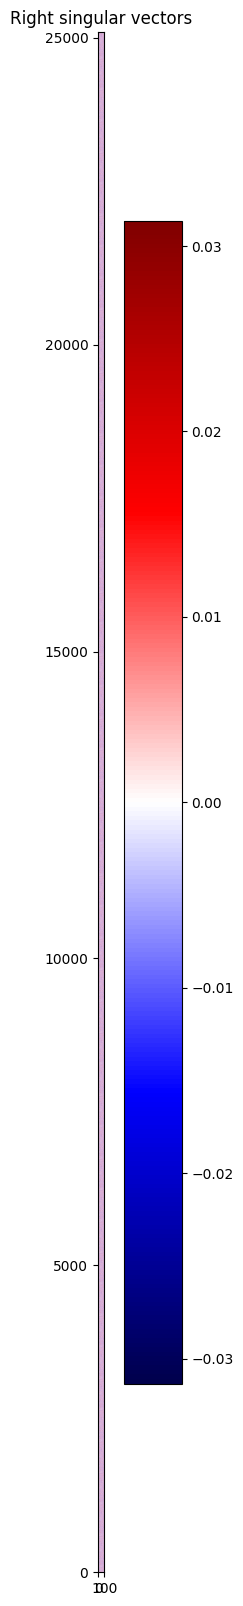

In [ ]:
print("\n5. Extracting significant features...\n")

plot_heatmap(
    np.transpose(svd_right_sing_vecs), 
    figsize=(5,20),
    title="Right singular vectors"
)

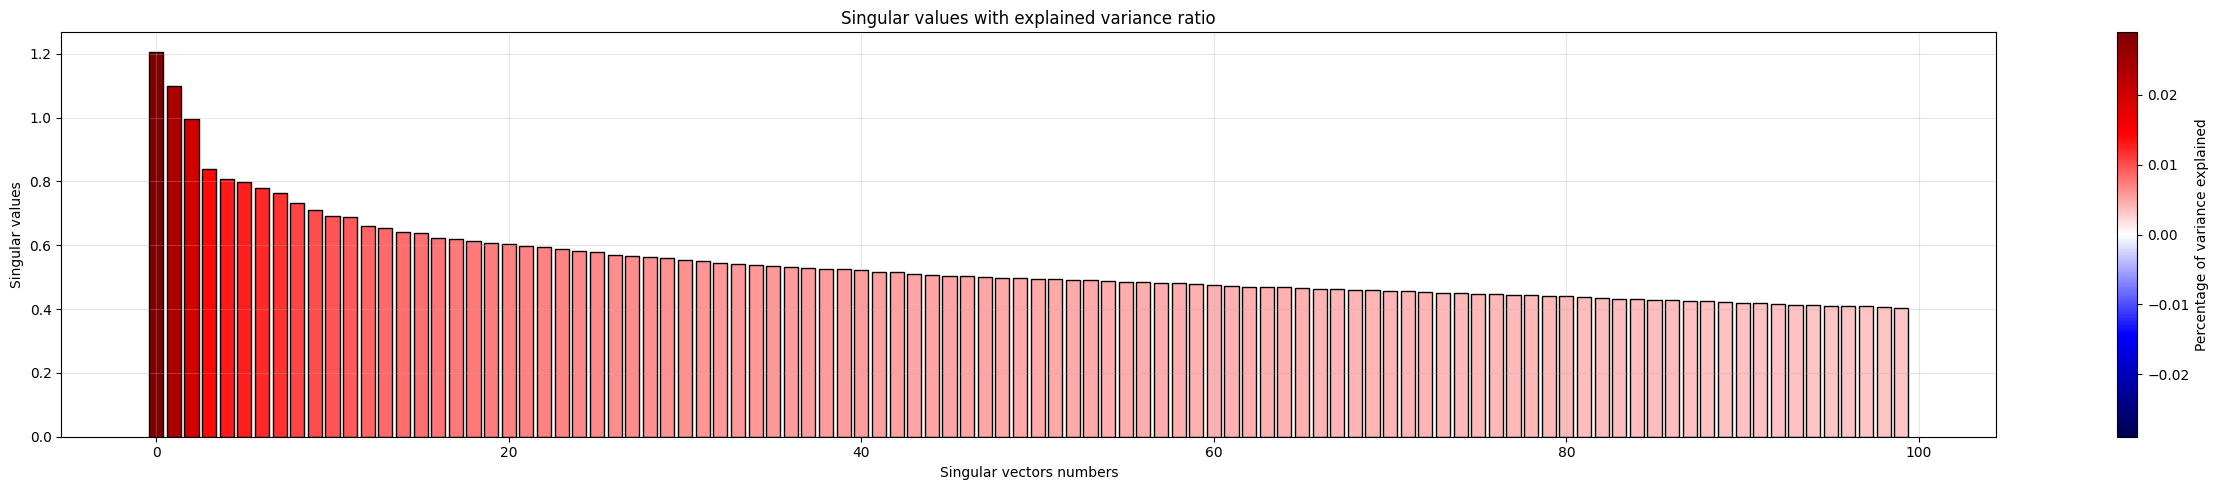

In [ ]:
svd_sing_values = svd.singular_values_
svd_expl_var_ratio = svd.explained_variance_ratio_

plot_colored_barplot(
    values=svd_sing_values,
    values_color=svd_expl_var_ratio,
    values_color_name="Percentage of variance explained",
    title="Singular values with explained variance ratio",
    xlabel="Singular vectors numbers",
    ylabel="Singular values"
)

In [ ]:
print("Top-5 singular values:                ", svd_sing_values[:5])
print("Top-5 (according) explained variences:", svd_expl_var_ratio[:5])

Top-5 singular values:                 [1.2071204  1.0980793  0.99501455 0.8394463  0.80831313]
Top-5 (according) explained variences: [0.02890488 0.02391868 0.01963941 0.01397836 0.01296067]


### Significant features count as: singular vectors, reduced features, reconstructed features

In [ ]:
def calc_ljust_spaces(signific_thresholds: list):
    n = 3
    
    thresholds_str = []
    for thr in signific_thresholds:
        thr_str = f"{thr:.{n}f}"
        thresholds_str.append(
            thr_str.rstrip('0').rstrip('.') if ('.' in thr_str) else thr_str
        )
    return thresholds_str, max(len(thr_str) for thr_str in thresholds_str) 


def signific_features_count(weights,
                            signific_thresholds: list,
                            weights_name: str = "",
                            is_strict: bool = False,
                            is_return: bool = False):
    signific_features_percent = {}
    thresholds_str, max_threshold_len = calc_ljust_spaces(signific_thresholds)
    
    signific_features_ns =  [ np.sum(np.abs(weights) > threshold) 
                             for threshold in signific_thresholds ] \
                            if is_strict else \
                            [ np.sum(np.abs(weights) >= threshold) 
                             for threshold in signific_thresholds ]

    print(f"    Percent of significant {weights_name} features:")
    sign = ">" if is_strict else ">="
    for i in range(len(signific_thresholds)):
        part = signific_features_ns[i] / weights.size
        print(
            f"        {sign} {thresholds_str[i].ljust(max_threshold_len)}: ", 
            f"{part:.5%}"        
        )
        signific_features_percent[thresholds_str[i]] = part * 100
    print("    of all features after SVD")
    
    return signific_features_percent \
           if is_return else None

In [ ]:
print("\n6.1 Counting significant singular features...\n")

signific_sing_thresholds = [0.01, 0.015, 0.02, 0.025, 0.05] # , 0.1, 0.15, 0.2, 0.25, 0.5, 0.75
signific_features_count(svd_right_sing_vecs, signific_sing_thresholds, "singular")


6.1 Counting significant singular features...

    Percent of significant singular features:
        >= 0.01 :  11.22656%
        >= 0.015:  1.88086%
        >= 0.02 :  0.22266%
        >= 0.025:  0.03516%
        >= 0.05 :  0.00000%
    of all features after SVD


In [ ]:
print("\n6.2 Counting significant reduced features...\n")

signific_red_thresholds = [0.01, 0.015, 0.02, 0.025, 0.05, 0.075, 0.1, 0.15] # 0.2, 0.25, 0.5, 0.75
signific_features_count(weights_reduced, signific_red_thresholds, "reduced")


6.2 Counting significant reduced features...

    Percent of significant reduced features:
        >= 0.01 :  53.59300%
        >= 0.015:  36.08100%
        >= 0.02 :  23.10800%
        >= 0.025:  14.17700%
        >= 0.05 :  1.11700%
        >= 0.075:  0.04800%
        >= 0.1  :  0.00100%
        >= 0.15 :  0.00000%
    of all features after SVD


In [ ]:
print("\n6.3 Counting significant reconstructed features...\n")

signific_rec_thresholds = [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.0075, 0.01] # , 0.1, 0.15, 0.2, 0.25, 0.5, 0.75
signific_features_count(
    weights_reconstructed, 
    signific_rec_thresholds, 
    "(binary in perspective) reconstructed"
)


6.3 Counting significant reconstructed features...

    Percent of significant (binary in perspective) reconstructed features:
        >= 0.001:  32.53457%
        >= 0.002:  14.92773%
        >= 0.002:  6.63183%
        >= 0.003:  3.22305%
        >= 0.005:  0.10293%
        >= 0.007:  0.00059%
        >= 0.01 :  0.00000%
        >= 0.015:  0.00000%
    of all features after SVD


## Codebook extraction experiments

In [ ]:
print("7. Fused weights inception for further experiments...")

resnet18_fused_fc = replace_fc_fused_weights(resnet18, picture_size)
output_resnet18_orig, output_resnet18_fused = verify_fusion_equivalence(resnet18, resnet18_fused_fc)
print(resnet18_fused_fc)

In [ ]:
print("\nValidating model after fusing avgpool with fc:")
top1_fused, top5_fused, val_time, _, _ = pretty_print_top1_top5_time(
    resnet18_fused_fc, val_loader,
    top1_orig, top5_orig
)

### Extractor class definition

In [58]:
class HammingCodebookExtractor:
    def __init__(self, 
                 max_codewords: int = 10,
                 divergence_type: str = "KL",
                 is_neighbor_refinement: bool = True,
                 neighbor_refinement_radius: int = 1,
                 divergence_limit: float = 1e-4,
                 codeword_threshold: float = 0.5,
                 max_iters: int = 100,
                 random_state: Optional[int] = None):
        """
        Parameters
        ----------
        max_codewords : int
            Maximum code words number. The upper limit for 
            codebook size = sum_{class in n_classes} len(codebook[class])
        divergence_type : str
            Logits divergence type, in {"KL", "L2"} (Kullback-Leibler or vector L2-norm)
        is_neighbor_refinement : bool
            Whether to use codewords local neighbor refinement during fitting
        neighbor_refinement_radius : int
            Hamming radius for neighbor refinement
        divergence_limit : float
            Divergence sufficient limit for fitting stop
        max_iters : int
            Maximum number of training iterations
        random_state : int
            Random seed number for reproducibility
        """
        self.max_codewords = max_codewords
        self.divergence_type = divergence_type
        self.codeword_threshold = codeword_threshold
        
        self.is_neighbor_refinement = is_neighbor_refinement
        self.neighbor_refinement_radius = neighbor_refinement_radius
        self.divergence_limit = divergence_limit
        self.max_iters = max_iters
        
        self.n_features = 0
        self.n_classes = 0
        self.codebook = [[]]  # list of 2D lists of different len
        self.lambda_scale = 0
        self.beta_bias = 0
        
        if random_state is not None:
            np.random.seed(random_state)
    
    # auxiliary methods
    
    def shape_checks(self,
                     X: np.ndarray,
                     y: np.ndarray,
                     t_logits: np.ndarray,
                     W: np.ndarray,):
        assert X.shape[0] == y.shape[0] == t_logits.shape[0], "`n_samples` are different for different objects"
        assert t_logits.shape[1] == self.n_classes, "Not all classes are presented in targets"
        if W is not None:
            assert (W.shape[0] == self.n_classes and W.shape[1] == self.n_features), "Wrong shape of weight matrix"

    def soft_hamming_distance(self, 
                              X: np.ndarray, 
                              codeword: np.ndarray) -> np.ndarray:
        """
        Compute soft Hamming distance between soft-binary vectors and binary codeword
        
        Parameters
        ----------
        X: np.ndarray, shape (n_samples, n_features)
            Soft-binary vectors
        codeword : np.ndarray, shape (n_features,)
            Binary codeword
            
        Returns
        --------
        distances : np.ndarray, shape (n_samples,)
            Hamming distance
        """
        return np.sum(X * (1 - codeword) + (1 - X) * codeword, axis=1)
    
    # initialization step
    
    def init_codebook(self, 
                      X: np.ndarray, 
                      y: np.ndarray, 
                      W: np.ndarray) -> None:
        """
        Codebooks initialization
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features
        y : np.ndarray, shape (n_samples,)
            Classes labels vector
        W : np.ndarray, shape (n_classes, n_features), optional
            fc.weights for bit calibration
        """        
        s_neg_feats = np.where( np.sign(np.sum(W, axis=0)) < 0 )[0]
        if len(s_neg_feats):
            X[:, s_neg_feats] = 1 - X[:, s_neg_feats]
        
        self.codebook = [[] for _ in range(self.n_classes)] 
        for class_i in range(self.n_classes):
            self.codebook[class_i].append(
                (np.mean(X[y == class_i], axis=0) >= self.codeword_threshold).astype(int)
            )

        self.calibrate_scale_bias(X, y)
    
    def calibrate_scale_bias(self, 
                             X: np.ndarray, 
                             y: np.ndarray, 
                             t_logits: Optional[np.ndarray] = None) -> None:
        """
        Calibration of coefficients lambda (scale) & beta (bias) in student computation
        from Hamming distance
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features
        y : np.ndarray, shape (n_samples,)
            Classes labels
        t_logits : np.ndarray, shape (n_samples, n_classes), optional
            Teacher's logits. When `None`, `t_logits` from `fit` is used
        """
        n_samples = X.shape[0]
        
        distances = np.zeros(n_samples)
        for i in range(n_samples):
            distances[i] = np.min([
                self.soft_hamming_distance(X[i:i+1], codeword)[0] 
                for codeword in self.codebook[y[i]]
            ])
        t_logits = t_logits or self.t_logits
        t_target = t_logits[np.arange(n_samples), y]
        
        # Linear regression: t_i \approx \alpha + \beta * d_i
        slope, intercept, r_value, p_value, std_err = stats.linregress(distances, t_target)
        self.lambda_scale = -slope
        self.beta_bias = intercept
        
    # fitting step
    
    def compute_divergence(self, 
                           t_logits: np.ndarray, 
                           s_logits: np.ndarray) -> np.ndarray:
        """
        Compute divergence between teacher & student logits
        
        Parameters
        -----------
        t_logits : np.ndarray, shape (n_samples, n_classes)
            Teacher logits
        s_logits : np.ndarray, shape (n_samples, n_classes)
            Student logits
            
        Returns
        --------
        divergence : np.ndarray, shape (n_samples,)
        """
        if self.divergence_type == "L2":
            return np.linalg.norm(t_logits - s_logits, axis=1)
        else:  # KL(σ(t) || σ(s))
            epsilon = 1e-12   # for log numerical stability
            t_probs = np.clip(softmax(t_logits, axis=1), epsilon, 1.0)
            s_probs = np.clip(softmax(s_logits, axis=1), epsilon, 1.0)
            return np.sum(t_probs * (np.log(t_probs) - np.log(s_probs)), axis=1)
            
    def compute_student_logits(self, X: np.ndarray) -> np.ndarray:
        """
        Compute student's logits for all classes
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary vectors
            
        Returns
        --------
        s_logits : np.ndarray, shape (n_samples, n_classes)
        """
        s_logits = np.zeros((X.shape[0], self.n_classes))
        for class_i in range(self.n_classes):
            min_dists = np.min(
                np.column_stack([
                    self.soft_hamming_distance(X, codeword) 
                    for codeword in self.codebook[class_i]
                ]), 
                axis=1
            )
            s_logits[:, class_i] = -self.lambda_scale * min_dists + self.beta_bias
        
        return s_logits
    
    def refine_codeword(self, 
                        X_class: np.ndarray, 
                        codeword_proto: np.ndarray, 
                        radius: int) -> np.ndarray:
        """
        Refine codeword via majority vote over neighbors of the same class 
        on soft Hamming distance over soft-bin features
        
        Parameters
        -----------
        X_class : np.ndarray, shape (n_class_samples, n_features)
            Same class samples
        codeword_proto : np.ndarray, shape (n_features,)
            codeword_proto codeword
        radius : int
            Upper limit for Hamming distance of same class samples
            closest to problematic one (~hierarchical clustering radius)
            
        Returns
        --------
        refined_codeword : np.ndarray, shape (n_features,)
            Refined codeword
        """
        neighbors = X_class[
            np.sum(
                (X_class >= self.codeword_threshold).astype(int) != (codeword_proto >= self.codeword_threshold).astype(int), 
                axis=1
            ) <= radius
        ]
        return (np.mean(neighbors, axis=0) >= self.codeword_threshold).astype(int) \
            if len(neighbors) else \
            codeword_proto.copy()
    
    def reassign_finetune(self, 
                          X: np.ndarray, 
                          y: np.ndarray) -> None:
        """
        Subclasses reassignation & codewords local finetuning
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features
        y : np.ndarray, shape (n_samples,)
            Classes labels
        """
        for class_i in range(self.n_classes):
            X_class_i = X[y == class_i]
            if not len(X_class_i):
                continue
            
            # find closest codeword for every sample
            codeword_closest = np.argmin(
                np.column_stack([
                    self.soft_hamming_distance(X_class_i, codeword) 
                    for codeword in self.codebook[class_i]
                ]), 
                axis=1
            )
            
            # update codewords as centers of the assigned clusters
            for codeword_i in range(len(self.codebook[class_i])):
                cluster_mask = (codeword_closest == codeword_i)
                
                if np.sum(cluster_mask) > 0:
                    cluster_samples = X_class_i[cluster_mask]
                    if self.is_neighbor_refinement:
                        refined_codeword = self.refine_codeword(
                            cluster_samples, 
                            self.codebook[class_i][codeword_i],
                            self.neighbor_refinement_radius
                        )
                        self.codebook[class_i][codeword_i] = refined_codeword
    
    def fit(self, 
            X: np.ndarray, 
            y: np.ndarray, 
            t_logits: np.ndarray,
            W: Optional[np.ndarray] = None) -> 'HammingCodebookExtractor':
        """
        Codebook extraction algorithm training
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features in [0,1]^n
        y : np.ndarray, shape (n_samples,)
            True labels in {0, 1, ..., C-1}
        t_logits : np.ndarray, shape (n_samples, n_classes)
            Teacher's logits
        W : np.ndarray, shape (n_classes, n_features), optional
            fc.weights for bit calibration
            
        Returns
        --------
        self : HammingCodebookExtractor
            Trained Hamming codebook extractor
        """
        self.n_features = X.shape[1]
        self.n_classes = len(np.unique(y))
        self.t_logits = t_logits
        
        self.shape_checks(X, y, W, t_logits)
        
        self.init_codebook(X, y, W)
        
        for iter in range(self.max_iters):
            print(f"Iteration {iter} started...")
            
            # 1. DIVERGENCE EVALUATION
            # student's logits computation 
            s_logits = self.compute_student_logits(X)
            print("S_LOGITS:", s_logits)
            divergences = self.compute_divergence(t_logits, s_logits)
            
            # divergence computation
            mean_divergence = np.mean(divergences)
            if mean_divergence < self.divergence_limit:
                print(f"EARLY STOP! Achieved mean divergence: {mean_divergence:.6f} - "
                      f"that is small enough")
                break
            print(f"    Mean divergence: {mean_divergence:.6f}")
            
            # class with max divergence search
            max_div = np.max(divergences)
            max_div_i = np.argmax(divergences)
            class_max_div = y[max_div_i]
            print(f"    Max divergence:  {max_div:.6f}")
            print(f"    Class with maximum divergence - {class_max_div}")
            
            # 2. NEW CODEWORD ADDITION
            # create a codeword prototype for the most problematic sample
            codeword_proto = (X[max_div_i] >= self.codeword_threshold).astype(np.float64)
            
            # refine new codeword if needed
            X_class = X[y == class_max_div]
            refined_codeword = self.refine_codeword(X_class, codeword_proto, self.neighbor_refinement_radius) \
                if (self.is_neighbor_refinement and len(X_class)) else \
                codeword_proto
            
            # 3. CLASSES RESIGNATION & FINETUNING
            self.codebook[class_max_div].append(refined_codeword)
            self.reassign_finetune(X, y)
            self.calibrate_scale_bias(X, y, t_logits)   
            
            if len(self.codebook) >= self.max_codewords:
                print(f"EARLY STOP! Reached maximum number of codewords")
                break
            
            # # compute new divergence to verify improvement
            # s_logits_new = self.compute_student_logits(X)
            # divergences_new = self.compute_divergence(t_logits, s_logits_new)
            # mean_divergence_new = np.mean(divergences_new)
            
            # print(f"    Divergence change: {mean_divergence:.6f} -> {mean_divergence_new:.6f}")
            
            # # if divergence didn't decrease significantly, remove the last codeword
            # if mean_divergence_new >= mean_divergence - 1e-6:
            #     print("    WARNING: No improvement after new codework addition, "
            #           f"removing last codeword for class {class_max_div}")
            #     self.codebook[class_max_div].pop()
            #     self.calibrate_scale_bias(X, y, t_logits)
        
        return self
    
    def predict_logits(self, X: np.ndarray) -> np.ndarray:
        """
        Compute student logits for new samples
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features
            
        Returns
        --------
        logits : np.ndarray, shape (n_samples, n_classes)
            Student's logits
        """
        return self.compute_student_logits(X)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Class prediction for new samples
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features

        Returns
        --------
        predictions : np.ndarray, shape (n_samples,)
            Predicted classes
        """
        return np.argmax(self.compute_student_logits(X), axis=1)
    
    def get_class_codewords(self, class_i: int) -> list:
        """
        All codewords for class by its id 
        
        Parameters
        -----------
        class_i : int
            Class id (number) 

        Returns
        --------
        class_codewords : np.ndarray, shape (n_codewords,)
            Predicted classes
        """
        return self.codebook[class_i]

### Preparation of training data for extractor

In [65]:
random_seed = 42

val_loader_len = 12800 # len(val_loader.dataset)
n_features = resnet18.fc.weight.data.cpu().numpy().shape[1]
max_codewords = val_loader_len // n_classes # type: ignore
divergence_type = "KL"

print(f"Training extractor: on {val_loader_len} training samples,\n"
      f"                    with maximum number of codewords per class: {max_codewords}\n", 
      f"                   for codewords of length: {n_features}")

Training extractor: on 12800 training samples,
                    with maximum number of codewords per class: 12
                    for codewords of length: 512


In [67]:
print("[ ] Getting training data for codebook extractor...")

soft_bin_features = np.zeros((val_loader_len, n_features), dtype=np.float32)
targets = np.zeros(val_loader_len, dtype=int)
t_logits = np.zeros((val_loader_len, n_classes), dtype=np.float32)

start_filling = 0

with torch.no_grad():
    for i, (images_batch, targets_batch) in enumerate(val_loader):
        if i * batch_size >= val_loader_len:
            break
        print(f"Processing batch {i}...")
        
        images_batch = images_batch.to(device, non_blocking=True)
        targets_batch = targets_batch.to(device, non_blocking=True)

        t_logits_batch = resnet18(images_batch)
        print("    Got logits of shape:", t_logits_batch.shape)
        print("    Avgpool input binarized into values:", avgpool_input_bin_values.data)
        
        end_filling = min(start_filling + batch_size, val_loader_len)
        soft_bin_features[ start_filling : end_filling ] = torch.nn.Sigmoid()(avgpool_input_bin).cpu().flatten(1).numpy()
        targets[ start_filling : end_filling ] = targets_batch.cpu().numpy()
        t_logits[ start_filling : end_filling ] = t_logits_batch.cpu().numpy()
        
        start_filling = end_filling
        
print("[V] Training data for codebook extractor prepared with:\n"
      f"    soft binary feature matrix shape:  {soft_bin_features.shape},\n" # [val_loader_len, n_features]
      f"    target vector shape:               {targets.shape},\n"           # [val_loader_len]
      f"    teacher model logits matrix shape: {t_logits.shape}")            # [val_loader_len, n_classes]

[ ] Getting training data for codebook extractor...
Processing batch 0...
    Got logits of shape: torch.Size([128, 1000])
    Avgpool input binarized into values: tensor([ 0.0000, 21.6274], device='cuda:0')


ValueError: could not broadcast input array from shape (128,25088) into shape (128,512)

In [29]:
print("Fused layer binary input values:      ", avgpool_input_bin_values)
print("have been transformed by sigmoid into:", torch.nn.Sigmoid()(avgpool_input_bin_values))

Fused layer binary input values:       tensor([ 0.0000, 21.6274], device='cuda:0')
have been transformed by sigmoid into: tensor([0.5000, 1.0000], device='cuda:0')


### Extractor usage

In [ ]:
print("[ ] Initializing codebook extractor...")
codebook_extractor = HammingCodebookExtractor(
    max_codewords=max_codewords,
    divergence_type=divergence_type,
    is_neighbor_refinement=True,
    neighbor_refinement_radius=10,
    divergence_limit=1e-4,
    max_iters=30,
    random_state=random_seed
)
print("[V] Codebook extractor ready for training")

[ ] Initializing codebook extractor...
[V] Codebook extractor ready for training


In [68]:
print("[ ] Codebook extractor training...")
codebook_extractor.fit(
    soft_bin_features, 
    targets, 
    t_logits, 
    weights_fused.cpu().numpy()
)
print("[V] Codebook extractor training finished")

[ ] Codebook extractor training...


AssertionError: `n_samples` are different for different objects

In [ ]:
codebooks = codebook_extractor.codebook
lambdas, betas = codebook_extractor.lambda_scale, codebook_extractor.beta_bias

print("Codebook parameters extracted:"
      "\n    Codebooks:\n",   codebooks,
      "\n    Lambdas:\n",     lambdas,
      "\n    Betas:\n",       betas)

Codebook parameters extracted:
    Codebooks:
 [[array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], [array([1., 1., 1., ..., 1., 1., 1.], shape=(25088,))], 

In [33]:
predictions = codebook_extractor.predict(soft_bin_features)
predictions

array([138,  86,  84, ...,  26, 148, 470], shape=(12800,))

## ADD-ONs

### Binarization scaling coefficient choice for avgpool input

In [66]:
print("[ ] Instantiating model...")
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT, progress=True)
resnet18.to(device)
print(f"[V] {resnet18_name} with default weights instantiated")

print("\nValidating model before binarizing:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(resnet18, val_loader)

[ ] Instantiating model...
[V] ResNet18 with default weights instantiated

Validating model before binarizing:
    Top-1 Accuracy:  69.7600
    Top-5 Accuracy:  89.0820
    Validation time: 71.5767 s


In [62]:
bin_values_choice_max_len = {}
bin_values_choice_max_values = {}

def update_bin_values_maxes(scale_k: float,
                            values_list: list):
    global bin_values_choice_max_len, bin_values_choice_max_values
    
    print("New max pseudobinary values found:")
    print(f"    quantization levels: {len(values_list)},\n"
          "    quantization values:", values_list)
    bin_values_choice_max_len[scale_k] = len(values_list)
    bin_values_choice_max_values[scale_k] = values_list

def binarize_hook_choice(module, input):    
    x, = input
    x_pseudobin = 2 ** (x+1).log2().mul(1/scale_k).round().mul(scale_k) - 1 # type: ignore

    global is_new_scale_k
    if is_new_scale_k:                                                      # type: ignore
        update_bin_values_maxes(scale_k, x_pseudobin.unique())              # type: ignore
        is_new_scale_k = False
    elif len(x_pseudobin.unique()) > bin_values_choice_max_len[scale_k]:    # type: ignore
        update_bin_values_maxes(scale_k, x_pseudobin.unique())              # type: ignore
    
    return (x_pseudobin,) 

In [67]:
top1_bins, top5_bins, drops1, drops5 = {}, {}, {}, {}

for scale in range(3, 21):  # from 0.75 to 5, step = 0.25 
    scale_k = scale/4
    print(f"\n\nBinarization with coeff {scale_k}:")
    
    print("[ ] Re-instantiating model...")
    resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT, progress=True)
    resnet18.to(device)
    print(f"[V] {resnet18_name} with default weights instantiated")

    print("\n[ ] Binarizing avgpool input...")
    resnet18.avgpool.register_forward_pre_hook(binarize_hook_choice)
    print(f"[V] Avgpool input binarization hook added")

    is_new_scale_k = True
    print("\nValidating model after binarizing avgpool input:")
    top1_bin, top5_bin, val_time, drop1, drop5 = pretty_print_top1_top5_time(
        resnet18, val_loader, 
        top1_orig=top1_orig, 
        top5_orig=top5_orig
    )
    
    top1_bins[scale_k] = top1_bin
    drops1[scale_k] = drop1
    top5_bins[scale_k] = top5_bin
    drops5[scale_k] = drop5



Binarization with coeff 0.75:
[ ] Re-instantiating model...
[V] ResNet18 with default weights instantiated

[ ] Binarizing avgpool input...
[V] Avgpool input binarization hook added

Validating model after binarizing avgpool input:
New max pseudobinary values found:
    quantization levels: 9,
    quantization values: tensor([ 0.0000,  0.6818,  1.8284,  3.7568,  7.0000, 12.4543, 21.6274, 37.0546,
        63.0000], device='cuda:0')
New max pseudobinary values found:
    quantization levels: 10,
    quantization values: tensor([  0.0000,   0.6818,   1.8284,   3.7568,   7.0000,  12.4543,  21.6274,
         37.0546,  63.0000, 106.6347], device='cuda:0')
    Top-1 Accuracy:  69.6900, drop: 0.0700
    Top-5 Accuracy:  89.0380, drop: 0.0440
    Validation time: 74.9777 s


Binarization with coeff 1.0:
[ ] Re-instantiating model...
[V] ResNet18 with default weights instantiated

[ ] Binarizing avgpool input...
[V] Avgpool input binarization hook added

Validating model after binarizing avgpo

In [72]:
for scale in range(41, 57):   # from 5.125 to 7, step = 0.125
    scale_k = scale/8
    print(f"\n\nBinarization with coeff {scale_k}:")
    
    print("[ ] Re-instantiating model...")
    resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT, progress=True)
    resnet18.to(device)
    print(f"[V] {resnet18_name} with default weights instantiated")

    print("\n[ ] Binarizing avgpool input...")
    resnet18.avgpool.register_forward_pre_hook(binarize_hook_choice)
    print(f"[V] Avgpool input binarization hook added")

    is_new_scale_k = True
    print("\nValidating model after binarizing avgpool input:")
    top1_bin, top5_bin, val_time, drop1, drop5 = pretty_print_top1_top5_time(
        resnet18, val_loader,
        top1_orig=top1_orig, 
        top5_orig=top5_orig
    )
    
    top1_bins[scale_k] = top1_bin
    drops1[scale_k] = drop1
    top5_bins[scale_k] = top5_bin
    drops5[scale_k] = drop5



Binarization with coeff 5.125:
[ ] Re-instantiating model...
[V] ResNet18 with default weights instantiated

[ ] Binarizing avgpool input...
[V] Avgpool input binarization hook added

Validating model after binarizing avgpool input:
New max pseudobinary values found:
    quantization levels: 2,
    quantization values: tensor([ 0.0000, 33.8962], device='cuda:0')
    Top-1 Accuracy:  66.5060, drop: 3.2540
    Top-5 Accuracy:  86.9160, drop: 2.1660
    Validation time: 77.9335 s


Binarization with coeff 5.25:
[ ] Re-instantiating model...
[V] ResNet18 with default weights instantiated

[ ] Binarizing avgpool input...
[V] Avgpool input binarization hook added

Validating model after binarizing avgpool input:
New max pseudobinary values found:
    quantization levels: 2,
    quantization values: tensor([ 0.0000, 37.0546], device='cuda:0')
    Top-1 Accuracy:  65.8620, drop: 3.8980
    Top-5 Accuracy:  86.4720, drop: 2.6100
    Validation time: 78.1185 s


Binarization with coeff 5.375:


In [73]:
scale_ks = sorted(drops1.keys())
drops1_truebin = { 
      scale_k: drops1[scale_k]
      for scale_k in scale_ks 
      if bin_values_choice_max_len[scale_k] <= 2 
}
drops5_truebin = { 
      scale_k: drops5[scale_k] 
      for scale_k in scale_ks 
      if bin_values_choice_max_len[scale_k] <= 2 
}

drop1_min = min(drops1_truebin.values())
drop5_min = min(drops5_truebin.values())

print(f"Minimal top-1 accuracy drop, {drop1_min:.2f}, ", 
      "is achieved with scaling coeff ", 
      list(filter(lambda k: drops1[k] == drop1_min, drops1_truebin)))
print(f"Minimal top-5 accuracy drop, {drop5_min:.2f}, ", 
      "is achieved with scaling coeff ", 
      list(filter(lambda k: drops5[k] == drop5_min, drops5_truebin)))

Minimal top-1 accuracy drop, 1.47,  is achieved with scaling coeff  [4.5]
Minimal top-5 accuracy drop, 0.94,  is achieved with scaling coeff  [4.5]


In [74]:
def plot_scale_k_metrics(metric_dicts: list[dict],
                         metric_names: list[str],
                         truebin_scale_ks: list = [],
                         cmap_name: str = "winter",
                         coeff_name: str = "",
                         figsize: tuple = (20, 7)):
    fig, ax = plt.subplots(figsize=figsize)
    metric_cmap = plt.get_cmap(cmap_name)
    max_metric = 0
    
    for i, metric_dict in enumerate(metric_dicts):
        scale_ks = sorted(metric_dict.keys())
        metric_values = [metric_dict[scale_k] for scale_k in scale_ks]
        max_metric = max(max_metric, max(metric_values))
        
        ax.plot(
            scale_ks, 
            metric_values, 
            marker='o', 
            color=metric_cmap(i / len(metric_dicts)),
            label=metric_names[i]
        )
    for truebin_scale_k in truebin_scale_ks:
        ax.axvline(
            truebin_scale_k, 
            alpha=0.8, lw=0.3,
            color = "red"
        )
    
    if max_metric > 90:
        y_ticks_metrics = [i for i in range(0, 101, 5)]
    elif max_metric < 5:
        y_ticks_metrics = [i*0.2 for i in range(0, 25)]
    elif max_metric < 10:
        y_ticks_metrics = [i*0.5 for i in range(0, int(max_metric) * 2)]
    else:
        y_ticks_metrics = [i for i in range(0, int(max_metric) + 6, 5)]
        
    ax.set(
        xticks=scale_ks,
        xlim=(min(scale_ks) - 0.01, max(scale_ks) + 0.01),
        xlabel="Scaling coefficient",
        yticks=y_ticks_metrics,
        ylabel="Accuracy (in %)",
        title="Accuracy dependance on " + coeff_name + " scaling coefficient"
    )
    ax.set_xticklabels(ax.get_xticks(), rotation=-90)
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.tight_layout()
    plt.show()

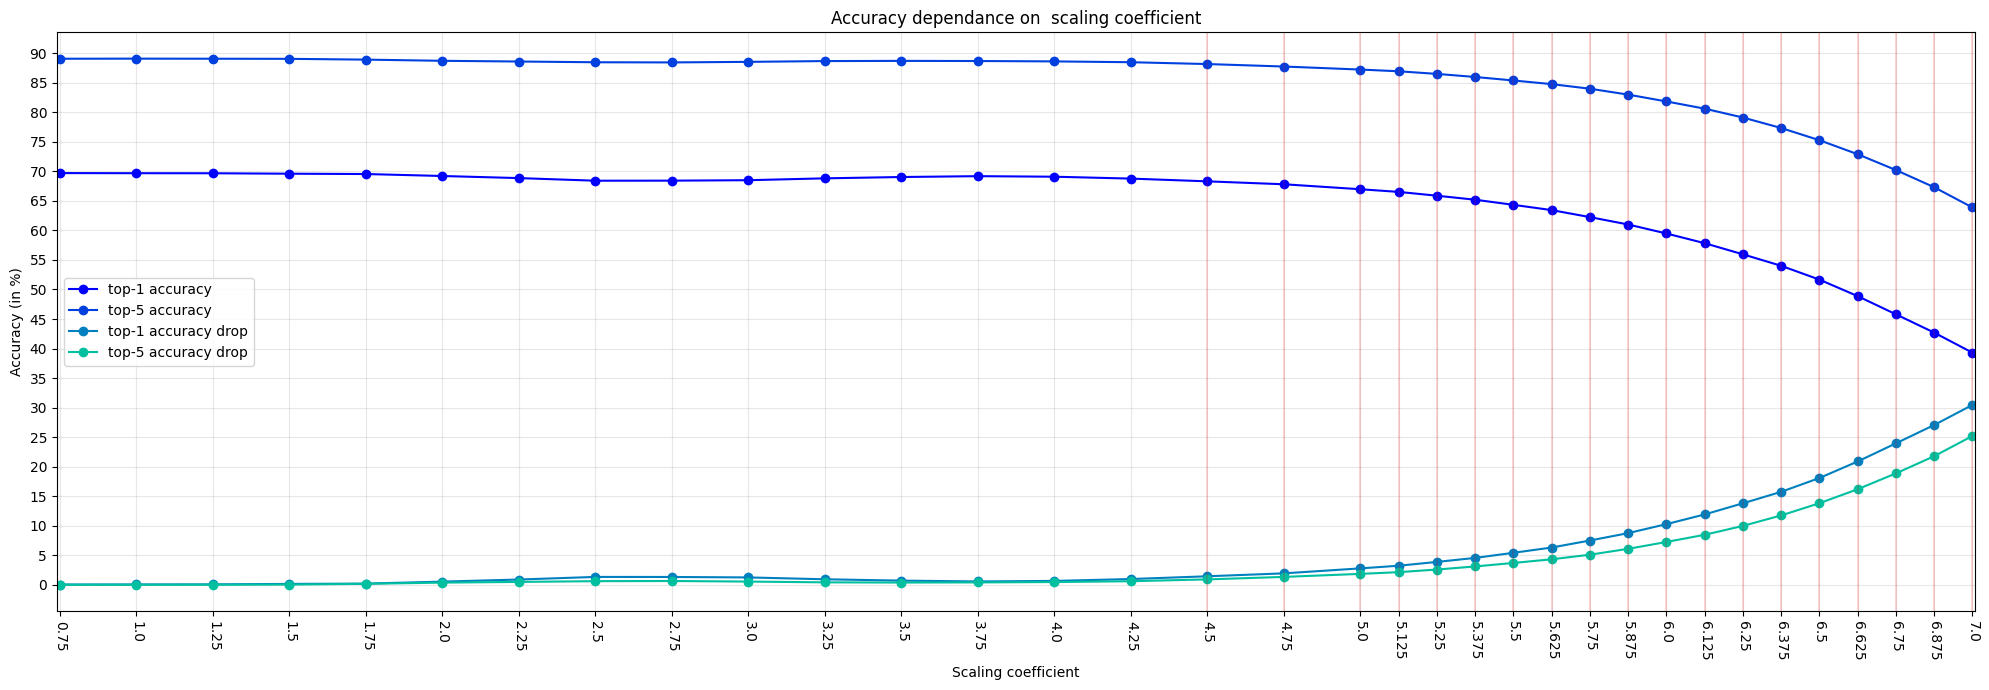

In [75]:
plot_scale_k_metrics(
    [top1_bins, top5_bins, drops1, drops5],
    ["top-1 accuracy", "top-5 accuracy", "top-1 accuracy drop", "top-5 accuracy drop"],
    drops1_truebin.keys() # type: ignore
)

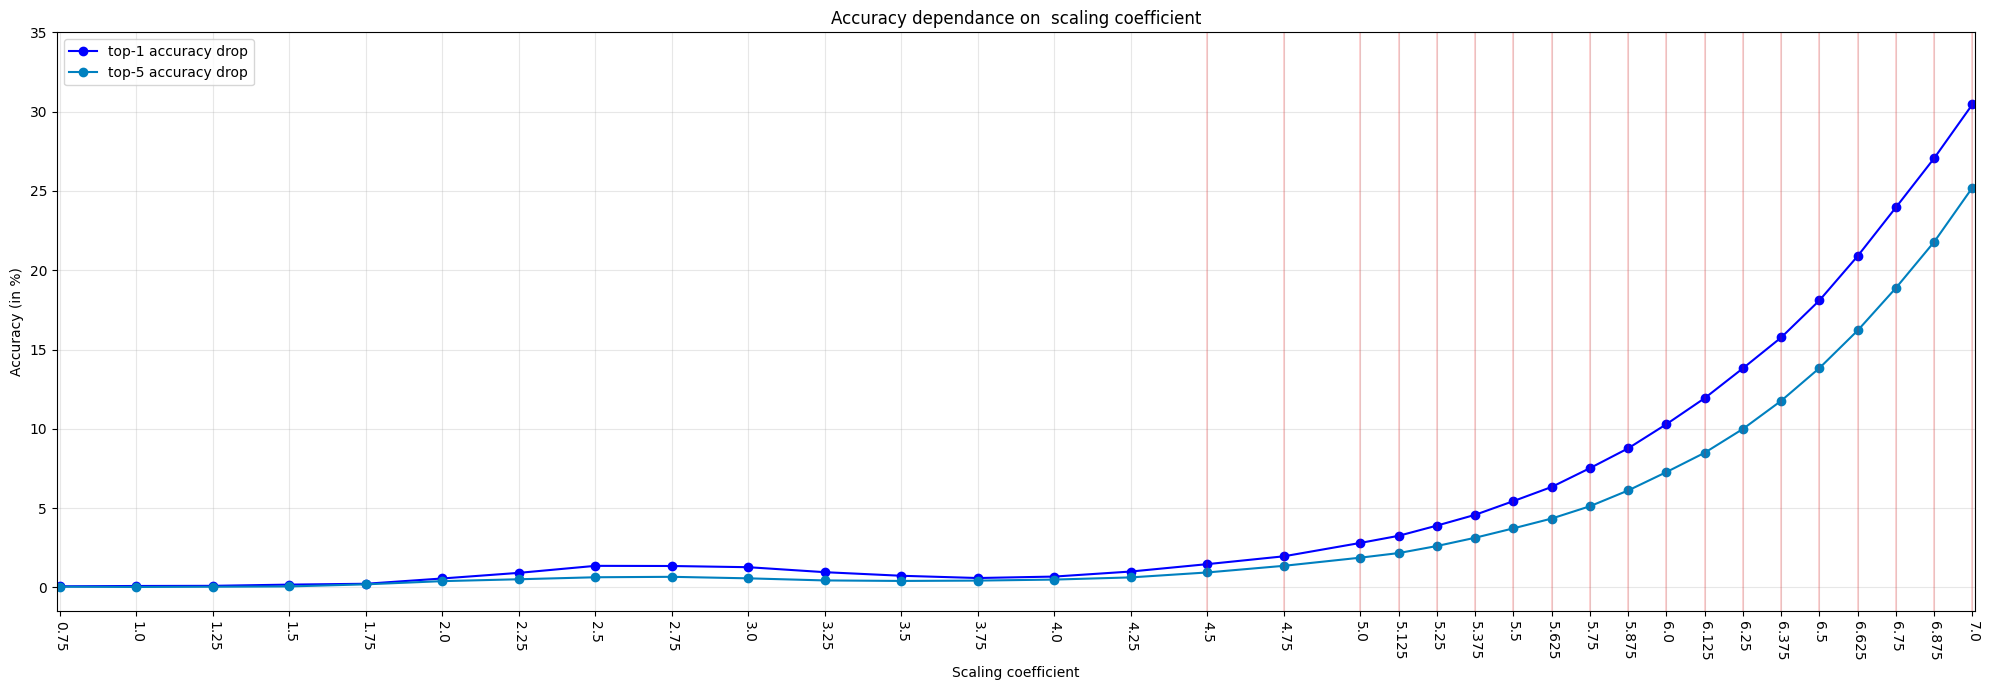

In [76]:
plot_scale_k_metrics(
    [drops1, drops5],
    ["top-1 accuracy drop", "top-5 accuracy drop"],
    drops1_truebin.keys() # type: ignore
)